In [37]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tqdm import tqdm
import os
import cv2
import random

In [38]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce GTX 1650


In [39]:
def corrupt_image(img):

    def noise(i):
        return np.clip(i + np.random.normal(0,20,i.shape),0,255).astype(np.uint8)

    def blur(i):
        return cv2.GaussianBlur(i,(5,5),0)

    def lowres(i):
        h,w=i.shape[:2]
        small=cv2.resize(i,(w//3,h//3))
        return cv2.resize(small,(w,h))

    return random.choice([noise,blur,lowres])(img)

In [40]:
class TestDataset(Dataset):

    def __init__(self, root_dir, img_size=224, limit=1000):

        self.paths=[os.path.join(root_dir,f) for f in os.listdir(root_dir)[:limit]]

        self.transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size,img_size))
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self,idx):

        img=cv2.imread(self.paths[idx])
        img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

        corrupted=corrupt_image(img.copy())

        return self.transform(corrupted), self.transform(img)

In [41]:
DATA_PATH = r"D:\Image Recognition\data"

dataset = TestDataset(DATA_PATH)

loader = DataLoader(dataset,batch_size=8,shuffle=False)

In [42]:
class Block(nn.Module):

    def __init__(self,a,b):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(a,b,3,1,1),
            nn.BatchNorm2d(b),
            nn.ReLU()
        )

    def forward(self,x):
        return self.net(x)


class ProcessingNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            Block(3,64),
            Block(64,64),

            nn.MaxPool2d(2),

            Block(64,128),
            Block(128,128),

            nn.Upsample(scale_factor=2),

            Block(128,64),

            nn.Conv2d(64,3,3,1,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [43]:
baseline = ProcessingNet().to(device)
baseline.load_state_dict(torch.load("baseline_model.pth",map_location=device))

ra18 = ProcessingNet().to(device)
ra18.load_state_dict(torch.load("RA_model.pth",map_location=device))

ra50 = ProcessingNet().to(device)
ra50.load_state_dict(torch.load("RA_model_resnet50.pth",map_location=device))

ra101 = ProcessingNet().to(device)
ra101.load_state_dict(torch.load("RA_model_resnet101.pth",map_location=device))

ra_vgg = ProcessingNet().to(device)
ra_vgg.load_state_dict(torch.load("RA_model_vgg16.pth",map_location=device))

ra_dense = ProcessingNet().to(device)
ra_dense.load_state_dict(torch.load("RA_model_densenet.pth",map_location=device))

ra_unsup = ProcessingNet().to(device)

ra_unsup.load_state_dict(
    torch.load("unsupervised_RA_model.pth", map_location=device)
)

<All keys matched successfully>

In [44]:
teacher = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

teacher = teacher.to(device)
teacher.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [45]:
normalize = transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225]
)

In [46]:
def evaluate(model):

    correct = 0
    total = 0

    with torch.no_grad():

        for corrupted,clean in tqdm(loader):

            corrupted = corrupted.to(device)
            clean = clean.to(device)

            restored = model(corrupted)

            gt = teacher(normalize(clean)).argmax(1)
            pred = teacher(normalize(restored)).argmax(1)

            correct += (gt==pred).sum().item()
            total += gt.size(0)

    return 100 * correct / total

In [47]:
b_acc = evaluate(baseline)
r18_acc = evaluate(ra18)
r50_acc = evaluate(ra50)
r101_acc = evaluate(ra101)
vgg_acc = evaluate(ra_vgg)
dense_acc = evaluate(ra_dense)
unsup_acc = evaluate(ra_unsup)


print("Baseline:",b_acc)
print("RA ResNet18:",r18_acc)
print("RA ResNet50:",r50_acc)
print("RA ResNet101:",r101_acc)
print("RA VGG16:",vgg_acc)
print("RA DenseNet:",dense_acc)
print("RA Unsupervised:", unsup_acc)

100%|██████████| 125/125 [00:38<00:00,  3.22it/s]

Baseline: 80.2
RA ResNet18: 80.7
RA ResNet50: 85.9
RA ResNet101: 82.2
RA VGG16: 80.2
RA DenseNet: 80.9
RA Unsupervised: 80.3


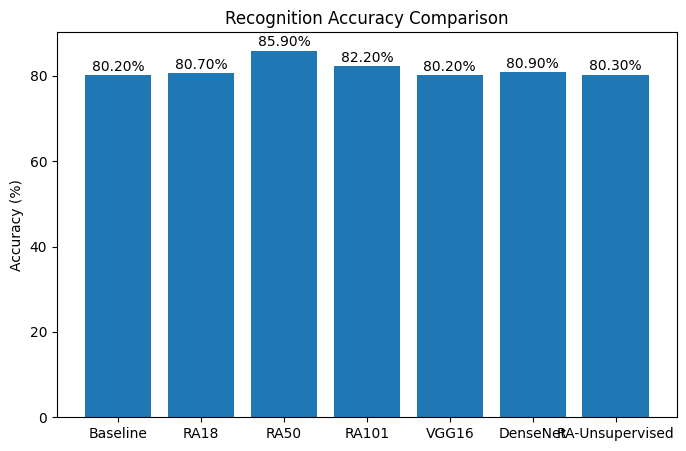

In [48]:
models = [
    "Baseline",
    "RA18",
    "RA50",
    "RA101",
    "VGG16",
    "DenseNet",
    "RA-Unsupervised"
]

accuracy = [
    b_acc,
    r18_acc,
    r50_acc,
    r101_acc,
    vgg_acc,
    dense_acc,
    unsup_acc
]

plt.figure(figsize=(8,5))

bars = plt.bar(models,accuracy)

plt.ylabel("Accuracy (%)")
plt.title("Recognition Accuracy Comparison")

for i,v in enumerate(accuracy):
    plt.text(i,v+1,f"{v:.2f}%",ha='center')

plt.show()

In [49]:
def recognition_confidence(img):

    with torch.no_grad():

        img = normalize(img).unsqueeze(0).to(device)

        logits = teacher(img)

        prob = torch.softmax(logits,dim=1)

        confidence = prob.max().item()

    return confidence

In [50]:
corrupted, clean = next(iter(loader))

corrupted = corrupted.to(device)

with torch.no_grad():

    baseline_out = baseline(corrupted).cpu()
    ra18_out = ra18(corrupted).cpu()
    ra50_out = ra50(corrupted).cpu()
    ra101_out = ra101(corrupted).cpu()
    vgg_out = ra_vgg(corrupted).cpu()
    dense_out = ra_dense(corrupted).cpu()

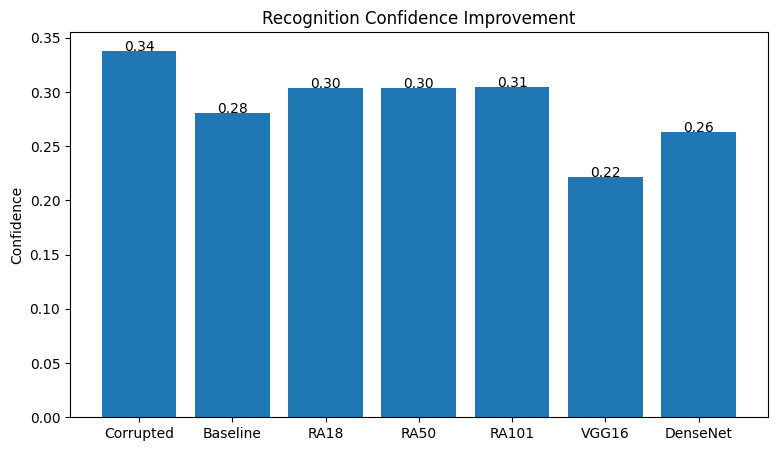

In [51]:
methods = ["Corrupted","Baseline","RA18","RA50","RA101","VGG16","DenseNet"]

scores = [
    recognition_confidence(corrupted[0].cpu()),
    recognition_confidence(baseline_out[0]),
    recognition_confidence(ra18_out[0]),
    recognition_confidence(ra50_out[0]),
    recognition_confidence(ra101_out[0]),
    recognition_confidence(vgg_out[0]),
    recognition_confidence(dense_out[0])
]

plt.figure(figsize=(9,5))

bars = plt.bar(methods,scores)

plt.ylabel("Confidence")
plt.title("Recognition Confidence Improvement")

for bar,score in zip(bars,scores):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{score:.2f}",
             ha='center')

plt.show()

In [52]:
def extract_features(model):

    feats=[]

    with torch.no_grad():

        for corrupted,clean in loader:

            restored = model(corrupted.to(device))

            f = teacher.avgpool(
                teacher.layer4(
                    teacher.layer3(
                        teacher.layer2(
                            teacher.layer1(
                                teacher.maxpool(
                                    teacher.relu(
                                        teacher.bn1(
                                            teacher.conv1(
                                                normalize(restored)
                                            )
                                        )
                                    )
                                )
                            )
                        )
                    )
                )
            )

            feats.append(f.view(f.size(0),-1).cpu().numpy())

    return np.concatenate(feats)

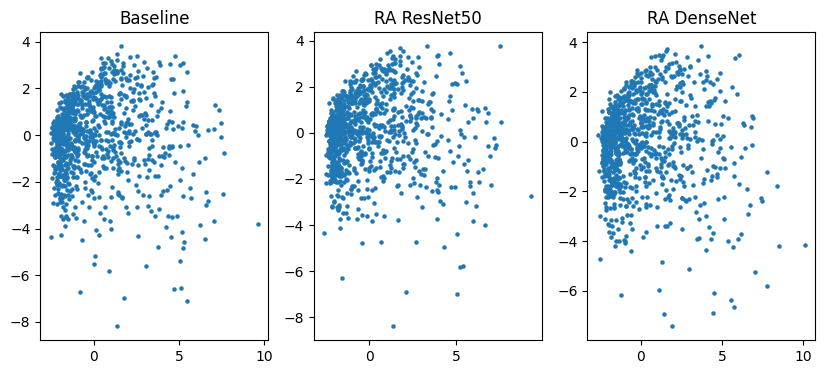

In [53]:
b_feat = extract_features(baseline)
r50_feat = extract_features(ra50)
dense_feat = extract_features(ra_dense)

pca = PCA(n_components=2)

pca.fit(np.concatenate([b_feat,r50_feat,dense_feat]))

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.scatter(*pca.transform(b_feat).T,s=5)
plt.title("Baseline")

plt.subplot(1,3,2)
plt.scatter(*pca.transform(r50_feat).T,s=5)
plt.title("RA ResNet50")

plt.subplot(1,3,3)
plt.scatter(*pca.transform(dense_feat).T,s=5)
plt.title("RA DenseNet")

plt.show()

Text(0.5, 1.0, 'RA-Unsupervised')

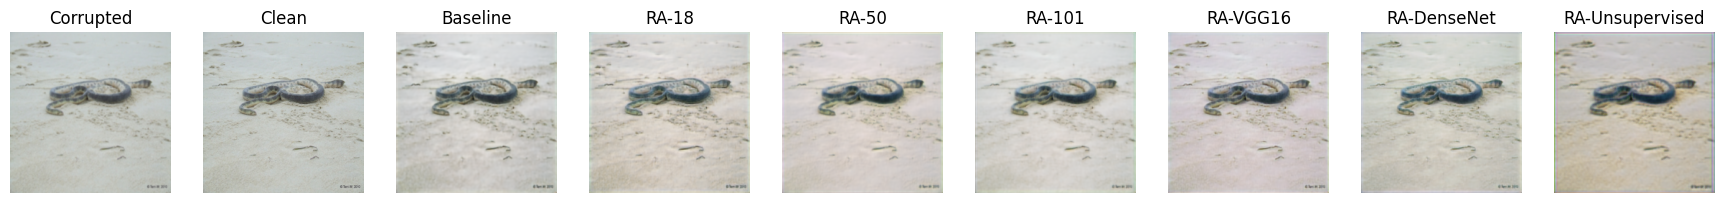

In [57]:
import matplotlib.pyplot as plt
import numpy as np

def show(img):
    
    img = img.detach().cpu().permute(1,2,0).numpy()
    img = np.clip(img,0,1)
    
    plt.imshow(img)
    plt.axis("off")


# get a batch
corrupted, clean = next(iter(loader))

corrupted = corrupted.to(device)

with torch.no_grad():
    
    baseline_out = baseline(corrupted).cpu()
    ra18_out = ra18(corrupted).cpu()
    ra50_out = ra50(corrupted).cpu()
    ra101_out = ra101(corrupted).cpu()
    vgg_out = ra_vgg(corrupted).cpu()
    dense_out = ra_dense(corrupted).cpu()
    unsup_out = ra_unsup(corrupted).cpu()

plt.figure(figsize=(22,4))

plt.subplot(1,9,1)
show(corrupted[0].cpu())
plt.title("Corrupted")

plt.subplot(1,9,2)
show(clean[0])
plt.title("Clean")

plt.subplot(1,9,3)
show(baseline_out[0])
plt.title("Baseline")

plt.subplot(1,9,4)
show(ra18_out[0])
plt.title("RA-18")

plt.subplot(1,9,5)
show(ra50_out[0])
plt.title("RA-50")

plt.subplot(1,9,6)
show(ra101_out[0])
plt.title("RA-101")

plt.subplot(1,9,7)
show(vgg_out[0])
plt.title("RA-VGG16")

plt.subplot(1,9,8)
show(dense_out[0])
plt.title("RA-DenseNet")

plt.subplot(1,9,9)
show(unsup_out[0])
plt.title("RA-Unsupervised")

In [58]:
def add_noise_level(img, sigma):

    img = img.permute(1,2,0).cpu().numpy()

    noise = np.random.normal(0, sigma, img.shape)

    noisy = np.clip(img + noise, 0, 1)

    noisy = torch.tensor(noisy).permute(2,0,1).float()

    return noisy

In [59]:
def recognition_confidence(img):

    with torch.no_grad():

        img = normalize(img).unsqueeze(0).to(device)

        logits = teacher(img)

        prob = torch.softmax(logits,dim=1)

        confidence = prob.max().item()

    return confidence

In [60]:
noise_levels = [0, 0.02, 0.05, 0.1, 0.15]

In [61]:
baseline_scores = []
ra18_scores = []
ra50_scores = []
ra101_scores = []
vgg_scores = []
dense_scores = []

corrupted, clean = next(iter(loader))

img = clean[0]

for noise in noise_levels:

    noisy = add_noise_level(img, noise).unsqueeze(0).to(device)

    with torch.no_grad():

        b = baseline(noisy).cpu()[0]
        r18 = ra18(noisy).cpu()[0]
        r50 = ra50(noisy).cpu()[0]
        r101 = ra101(noisy).cpu()[0]
        vgg = ra_vgg(noisy).cpu()[0]
        dense = ra_dense(noisy).cpu()[0]

    baseline_scores.append(recognition_confidence(b))
    ra18_scores.append(recognition_confidence(r18))
    ra50_scores.append(recognition_confidence(r50))
    ra101_scores.append(recognition_confidence(r101))
    vgg_scores.append(recognition_confidence(vgg))
    dense_scores.append(recognition_confidence(dense))

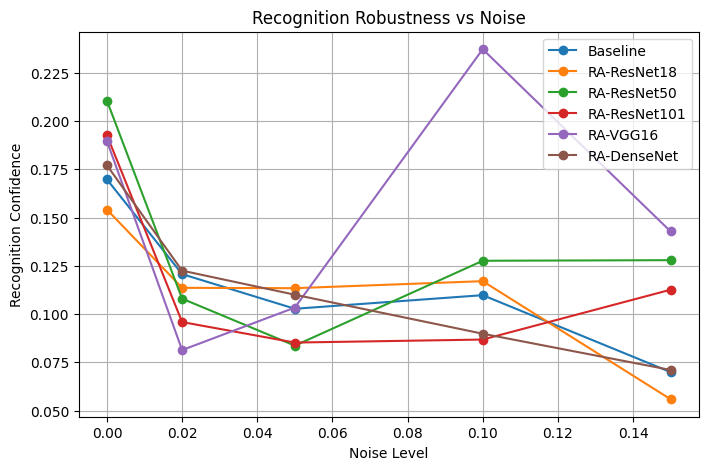

In [62]:
plt.figure(figsize=(8,5))

plt.plot(noise_levels, baseline_scores, marker="o", label="Baseline")
plt.plot(noise_levels, ra18_scores, marker="o", label="RA-ResNet18")
plt.plot(noise_levels, ra50_scores, marker="o", label="RA-ResNet50")
plt.plot(noise_levels, ra101_scores, marker="o", label="RA-ResNet101")
plt.plot(noise_levels, vgg_scores, marker="o", label="RA-VGG16")
plt.plot(noise_levels, dense_scores, marker="o", label="RA-DenseNet")

plt.xlabel("Noise Level")
plt.ylabel("Recognition Confidence")
plt.title("Recognition Robustness vs Noise")

plt.legend()
plt.grid()

plt.show()